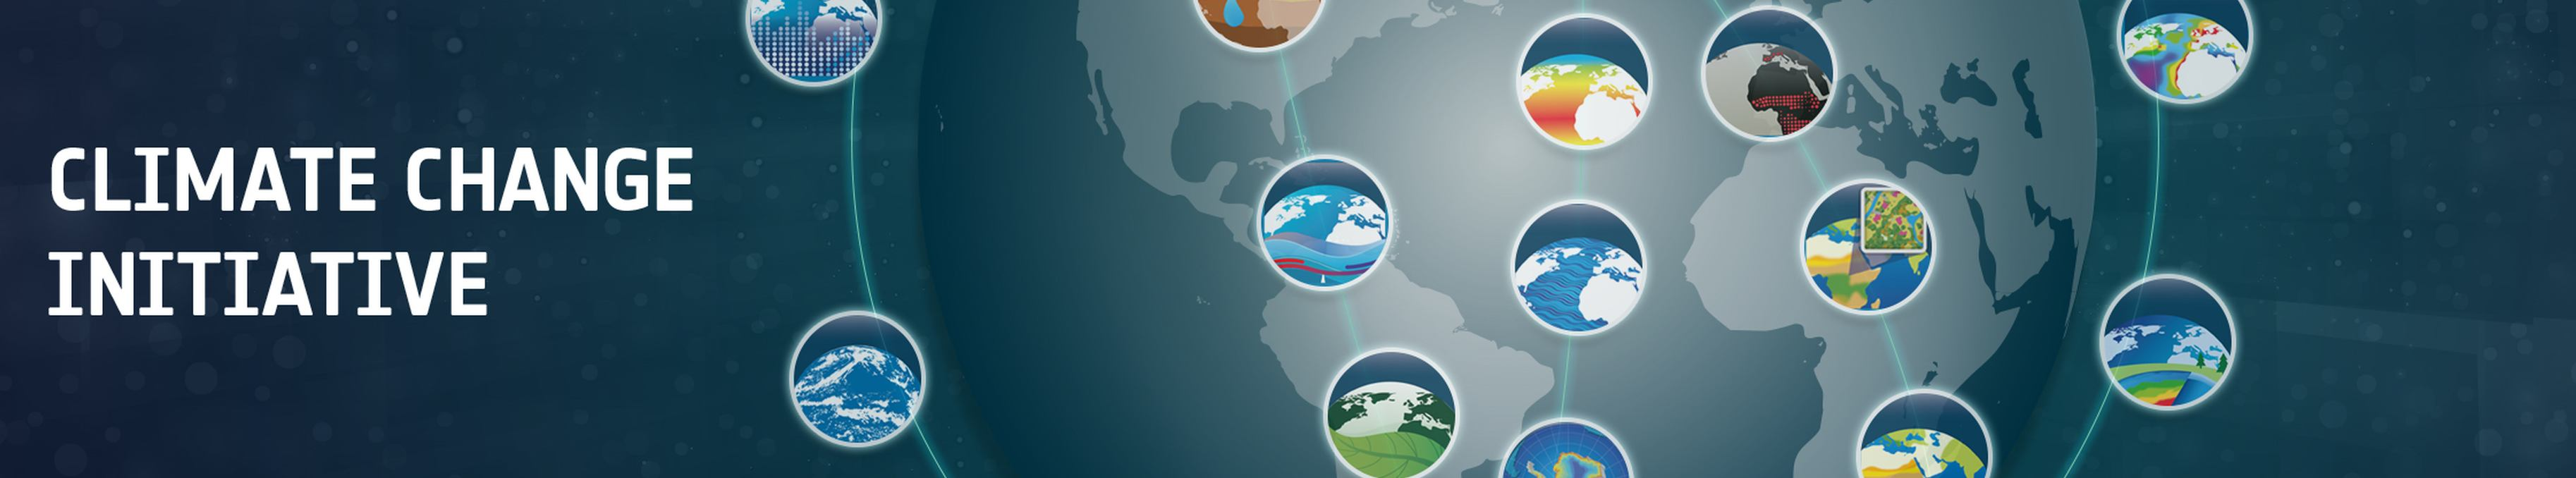

# Introduction

In October 2017, a series of devastating wildfires swept across Northern Portugal and Northwestern Spain, burning over 500,000 hectares in Portugal alone. What made these fires so extreme? In this notebook, we'll investigate that question using real satellite climate data from ESA's Climate Change Initiative (CCI).
By working through this notebook, you will :

- Learn to access and visualise ESA-CCI's ECVs
- Explore ESA-CCI's Fire data to analyse patterns across the Iberian Peninsula in 2017
- Analyse ESA-CCI's Soil Moisture anomalies to assess pre-fire drought conditions
- Examine ESA-CCI's Land Surface Temperature anomalies during the fire period
- Quantify ESA-CCI's Biomass loss caused by the fires using before/after comparisons


Prerequisites: Basic Python familiarity and some experience with NumPy or pandas. No prior experience with satellite data is required.
Estimated time: ~2 hours

🛠️ Tools We'll Use
We'll rely on the [ESA Climate Toolbox](https://esa-climate-toolbox.readthedocs.io/en/latest/) which simplifies access, manipulation, and visualisation of CCI datasets in Python.

New to the toolbox? For a broader introduction to the toolbox and how to install it, visit:  

🔗 [ESA CCI Climate Toolbox Quick Start](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks)  
🔗 [ESA Climate Data Toolbox Website](https://climate.esa.int/en/data/toolbox/)


The Toolbox package allows us to:

- Access satellite-based climate data records from ESA's Climate Change Initiative (CCI).
- Handle geospatial and temporal dimensions efficiently.
- Aggregate and visualise climate data with intuitive plotting tools spatially and temporally.


Learning objectives:

By the end of this notebook, you will be able to:
- Load and subset ESA CCI satellite datasets
- Calculate climatological anomalies
- Correlate multiple ECVs to a real-world extreme weather ev

In [1]:
# ESA Climate Toolbox imports for accessing and plotting ESA CCI data
from esa_climate_toolbox.core import get_op              # Get predefined operations (e.g., time series, averages)
from esa_climate_toolbox.core import list_ecv_datasets   # List available datasets per ECV (Essential Climate Variable)
from esa_climate_toolbox.core import get_store           # Connect to an ESA data store
from esa_climate_toolbox.core import list_datasets       # List all datasets in a store
from esa_climate_toolbox.core import search
from esa_climate_toolbox.ops import plot                 # High-level plotting functions for CCI data
from esa_climate_toolbox.ops import temporal_aggregation

# Used for connecting to remote data sources (e.g., ESA CCI ODP)
from xcube.core.store import new_data_store

# For displaying geographic regions interactively (if desired)
from IPython.display import GeoJSON
import shapely.geometry   # Handling geometric objects like bounding boxes

# Core data science libraries
import pandas as pd       # For tabular data handling and time manipulation
import numpy as np        # For numerical operations
import xarray as xr       # For multi-dimensional climate data structures

# Mapping and plotting
import matplotlib.pyplot as plt       # Plotting library
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs            # Cartographic projections for spatial data
import cartopy.feature as cfeature
import rasterio                       # Used to read GeoTIFF files

# Individual colormap creation
from matplotlib.colors import ListedColormap, BoundaryNorm

# Notebook settings
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

## Motivation 

This notebook will give some examples on different pressure-impact scenarios and look at the areas where they come into play on the Iberian Peninsula. 

As satellite data is rather large, the best practice is to minimise the data load by reducing it to an area of interest. 

### Real-World Application: Analysing the 2017 Iberian Wildfires with CCI Data

💡 In October 2017 Northern Portugal and Northwestern Spain experienced a series of forest fires. The fires had been fueled by strong winds from a previous Hurricane Ophelia. 
A study published in Nature Scientific Reports by [Turco et al. (2019)](https://www.nature.com/articles/s41598-019-50281-2) analysed the climatic factors which led to the extent of the fires. Alone in Portugal about 500 000 hectars were burned down by fires in 2017, where two fire events were happening - one from 17 - 20 June, the other from 15-17 October 2017. 

Several factors played a role in causing the extent of the fires. The year has been extremely dry and hot, both factors which have been shown to promote strong wild fires ([Turco et al., 2017](https://www.nature.com/articles/s41598-017-00116-9)).


➡️ Now, let's have a look at the satellite data ourselves and determine the conditions which favoured the wildfires in 2017.


👉 Let's start by looking at the monthly burned area on the Iberian Peninsula to narrow down to an area which has been majorly impacted. 

### 🛰️ CCI FIRE
We will use the data products from the [CCI Fire](https://climate.esa.int/en/projects/fire/) project and look at the burned areas. Details about the dataset can be found on the project website and the provided [Product User Guide](https://climate.esa.int/media/documents/Fire_cci_D4.2.1_PUG-MODIS_v1.1.pdf).  

With the command `list_ecv_datasets('Fire')`, we can call a list of all available CCI Fire datasets which can be loaded via the esa-climate-toolbox.

Before loading the data, we can inspect its structure and look at the attributes, data variables, dimensions, etc. by using the toolbox command `describe_data`.

In [ ]:
list_ecv_datasets('Fire')

We will use the MODIS_TERRA dataset as it contains pixel data in a high resolution which suits our purpose very well. 

As first step, we have a look at the potential opener parameters.

In [2]:
fire_dataset = "esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel"

In [5]:
cci_store = new_data_store('esa-cci')
cci_store.get_open_data_params_schema(fire_dataset)

🔍 What do we learn from the details?

The temporal resolution of the burned area data is monthly and covers 2001 - 2022. The spatial resolution is 0.0022° which corresponds to a pixel size of approximately 250 m x 250 m on the Iberian Peninsula. The unit of the burned area is m<sup>2</sup>.


From the [Product User Guide](https://climate.esa.int/media/documents/Fire_cci_D4.2.1_PUG-MODIS_v1.1.pdf) we can get the information on the Areas. The table is also shown here for your convenince. 
For the Iberian Wildfires, we need the Area 3. 

| Area | Name | Upper Left | Lower Right |
|------|------|------------|-------------|
| 1 | North America | 180°W, 83°N | 50°W, 19°N |
| 2 | South America | 105°W, 19°N | 34°W, 57°S |
| 3 | Europe – North Africa | 26°W, 83°N | 53°E, 25°N |
| 4 | Asia | 53°E, 83°N | 180°E, 0°N |
| 5 | Sub-Saharan Africa | 26°W, 25°N | 53°E, 0°N |
| 6 | Australia & New Zealand | 95°E, 40°S | 180°E, 53°S |


In [6]:
places = ["AREA_3"]

In [7]:
# now we use the data file name and the places we defined to open the data tree:
fire_dt = cci_store.open_data(
    fire_dataset,
    place_names=places
)
fire_dt

<xarray.DataTree 'esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel'>
Group: /
└── Group: /
        Dimensions:    (time: 264, y: 25827, x: 35178, bnds: 2)
        Coordinates:
          * time       (time) datetime64[ns] 2kB 2001-01-16T12:00:00 ... 2022-12-16T1...
            time_bnds  (time, bnds) datetime64[ns] 4kB dask.array<chunksize=(264, 2), meta=np.ndarray>
          * x          (x) float64 281kB -26.0 -26.0 -26.0 -25.99 ... 52.99 53.0 53.0
          * y          (y) float64 207kB 83.0 83.0 82.99 82.99 ... 25.01 25.01 25.0 25.0
        Dimensions without coordinates: bnds
        Data variables:
            CL         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
            JD         (time, y, x) int16 480GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
            LC         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
        Attributes:
            Conventions:             CF-1.7
         

Next, we put the data into an xarray format: 

In [8]:
ds = fire_dt.get(places[0]).to_dataset()
ds

<xarray.Dataset> Size: 959GB
Dimensions:    (time: 264, y: 25827, x: 35178, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2001-01-16T12:00:00 ... 2022-12-16T1...
    time_bnds  (time, bnds) datetime64[ns] 4kB dask.array<chunksize=(264, 2), meta=np.ndarray>
  * x          (x) float64 281kB -26.0 -26.0 -26.0 -25.99 ... 52.99 53.0 53.0
  * y          (y) float64 207kB 83.0 83.0 82.99 82.99 ... 25.01 25.01 25.0 25.0
Dimensions without coordinates: bnds
Data variables:
    CL         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
    JD         (time, y, x) int16 480GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
    LC         (time, y, x) uint8 240GB dask.array<chunksize=(1, 8609, 451), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v...
    date_created:            2026-04-17T12:27:10.948703
    processing_level:        L3S
    time_coverage_start:     2001-01-01T00:00:00
    time_coverage_end:       2023-01-01T00:00:00
    time_coverage_duration:  P8035DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

We see that the lat and lon dimensions are labelled as x and y, let's change this in a next step: 

In [15]:
ds = ds.rename({"x": "lon", "y": "lat"})  

Since we want to focus on the fires from 2017, we will reduce the dataset to this year 


In [13]:
import datetime as dt
ds_2017 = ds.sel(time=ds.time.dt.year == 2017)  # then filterint for 2017

In [10]:
print(ds_2017.time.values)        
print(ds_2017.JD)               

['2017-01-16T12:00:00.000000000' '2017-02-15T00:00:00.000000000'
 '2017-03-16T12:00:00.000000000' '2017-04-16T00:00:00.000000000'
 '2017-05-16T12:00:00.000000000' '2017-06-16T00:00:00.000000000'
 '2017-07-16T12:00:00.000000000' '2017-08-16T12:00:00.000000000'
 '2017-09-16T00:00:00.000000000' '2017-10-16T12:00:00.000000000'
 '2017-11-16T00:00:00.000000000' '2017-12-16T12:00:00.000000000']
<xarray.DataArray 'JD' (time: 12, lat: 25827, lon: 35178)> Size: 22GB
dask.array<getitem, shape=(12, 25827, 35178), dtype=int16, chunksize=(1, 8609, 451), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2017-01-16T12:00:00 ... 2017-12-16T12:...
  * lon      (lon) float64 281kB -26.0 -26.0 -26.0 -25.99 ... 52.99 53.0 53.0
  * lat      (lat) float64 207kB 83.0 83.0 82.99 82.99 ... 25.01 25.01 25.0 25.0
Attributes:
    crs_wkt:           GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",637...
    dimensions:        ['time', 'y', 'x']
    file_dimensions:   ['time', 'y', 'x']

In [47]:
# Load the dataset
# fire_ds = cci_zarr_store.open_data('ESACCI-L4_FIRE-BA-MODIS-2001-2022-fv5.1.zarr')
# fire_ds

#### Zooming In - Defining a Region of Interest
Let's reduce the data size and focus on the Iberian Peninusla first. We define a bounding box and apply the `subset_spatial`operation from the esa-climate-toolbox. 

In [11]:
# Set bounding box by defining the longitude minimum, latitude minimum, longitude maximum and latitude maximum
bbox_iberianpeninsula = (-10, 35.0, 5, 44.0) # Iberian Peninsula
bbox_west = (-8.8, 39.0, -7.5, 43.0) # West part of Ib. Pen. 

# Display bounding box for reference
GeoJSON(shapely.geometry.box(*bbox_west).__geo_interface__)

<IPython.display.GeoJSON object>

In [12]:
ds.JD.attrs

{'crs_wkt': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]',
 'dimensions': ['time', 'y', 'x'],
 'file_dimensions': ['time', 'y', 'x'],
 'size': 239855142384,
 'shape': [264, 25827, 35178],
 'data_type': 'int16',
 'chunk_sizes': [1, 8609, 451],
 'file_chunk_sizes': [1, 8609, 451]}

### Building the subset 
Now we will build a spatial subset of the data from 2017 to focus on the area where most fires have occured.

In [17]:
subset_spatial_op = get_op('subset_spatial')

ds_2017_sub = subset_spatial_op(ds_2017, region=bbox_west)
ds_sub=subset_spatial_op(ds, region=bbox_west)

In [18]:
ds.CL.sel(time="2017-10").max().compute() #where confidence level =!0 : fire occured

<xarray.DataArray 'CL' ()> Size: 1B
array(100, dtype=uint8)

In [19]:
#conversion of dates julian 
#Oct 1 JD ≈ 274
#Oct 15 JD ≈ 288
#Oct 31 JD ≈ 304pxl_burned_17 = ds_2017_sub.JD.where(ds.CL > 0)
pxl_burned_17 = ds_2017_sub.JD.where(ds.CL > 0)
pxl_burned_17

<xarray.DataArray 'JD' (time: 12, lat: 1782, lon: 580)> Size: 50MB
dask.array<where, shape=(12, 1782, 580), dtype=float32, chunksize=(1, 1782, 443), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2017-01-16T12:00:00 ... 2017-12-16T12:...
  * lon      (lon) float64 5kB -8.8 -8.798 -8.795 -8.793 ... -7.504 -7.502 -7.5
  * lat      (lat) float64 14kB 43.0 43.0 43.0 42.99 ... 39.01 39.01 39.0 39.0
Attributes:
    crs_wkt:           GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",637...
    dimensions:        ['time', 'y', 'x']
    file_dimensions:   ['time', 'y', 'x']
    size:              239855142384
    shape:             [264, 25827, 35178]
    data_type:         int16
    chunk_sizes:       [1, 8609, 451]
    file_chunk_sizes:  [1, 8609, 451]

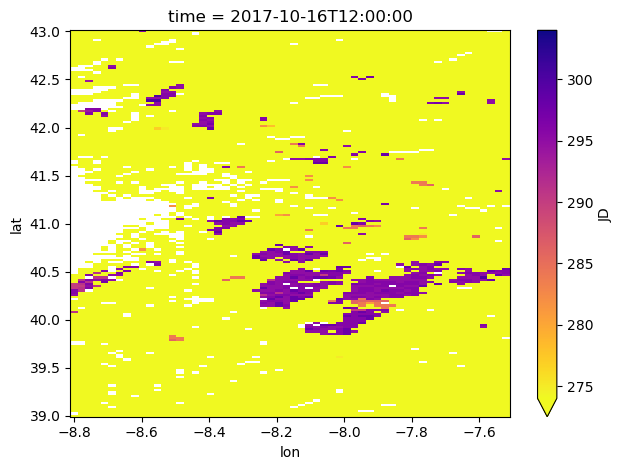

In [28]:
pxl_burned_17.sel(time='2017-10-16', method='nearest').isel(
    lon=slice(0, 35178, 10), # here we slice the data an only take every 10th entry to reduce the data to be plotted. The length of lat and lon can be found above when inspecting the dataset
    lat=slice(0, 25827, 10)
).plot(cmap='plasma_r', vmin=274, vmax=304) # for vmin and vmax we set it to the julian day (JD) of October 1st and 31st

Most burnt pixels have low JD Values so fires happened earlier in october,
and  in a few areas in the South-West. Now if we want to look more at the fire extent we can compute the burned area

In [21]:
ds_sub

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 264, lat: 1782, lon: 580, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2001-01-16T12:00:00 ... 2022-12-16T1...
    time_bnds  (time, bnds) datetime64[ns] 4kB dask.array<chunksize=(264, 2), meta=np.ndarray>
  * lon        (lon) float64 5kB -8.8 -8.798 -8.795 ... -7.504 -7.502 -7.5
  * lat        (lat) float64 14kB 43.0 43.0 43.0 42.99 ... 39.01 39.01 39.0 39.0
Dimensions without coordinates: bnds
Data variables:
    CL         (time, lat, lon) uint8 273MB dask.array<chunksize=(1, 1782, 8), meta=np.ndarray>
    JD         (time, lat, lon) int16 546MB dask.array<chunksize=(1, 1782, 8), meta=np.ndarray>
    LC         (time, lat, lon) uint8 273MB dask.array<chunksize=(1, 1782, 8), meta=np.ndarray>
Attributes: (12/16)
    Conventions:                CF-1.7
    title:                      esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERR...
    date_created:               2026-04-17T12:27:10.948703
    processing_level:           L3S
    time_coverage_start:        2001-01-01T00:00:00
    time_coverage_end:          2023-01-01T00:00:00
    ...                         ...
    geospatial_lon_max:         -7.498502844663786
    geospatial_lat_resolution:  0.00224573310710241
    geospatial_lat_min:         38.99940113783811
    geospatial_lat_max:         43.00129753468411
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-8.801028046774942 38.99940113783811...

In [29]:
pxl_burned = ds_sub.CL > 0

In [30]:
#COmputing burned area 
burned_area = pxl_burned.sum(dim=["lat", "lon"]) 

In [31]:
burned_area

<xarray.DataArray 'CL' (time: 264)> Size: 2kB
dask.array<sum-aggregate, shape=(264,), dtype=int64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2001-01-16T12:00:00 ... 2022-12-16T12:...

Now that we have created a subset, we can take care of a proper visualisation of the JD variable. As a matter of fact, this variable has a special encoding. The value 0 indicates that a pixel has not been burned, -1 stands for pixels that were not observed in the month (e.g., due to high cloud coverage), and -2 stands for pixels that cannot be burned due to the type of land cover. For all other pixels, the values between 1-366 denote the day of year in which first a fire was detected. The dataset is divided into months, meaning that for January the value range is between 1 and 31, for February 32 to 59, and so on. We aim to go for a visualisation where the julian day is scaled for each month to the same scale of red shades. But first, we define the colors, values and labels for the three catagories between -2 and 0.

In [33]:
base_category_colors = [
    "#1e90ff",  # dodger blue
    "#91a3b0",  # cadet grey
    "#000000",  # black
]
base_category_labels = [
    "Non-burnable",
    "Not observed",
    "Unburnt"
]
base_category_values = [-2, -1, 0]

Now we can continue with the definition of the red color range. For this, we take the predefined "Reds" color map from the matplotlib package and divide it into 31 categories. We already add the first three colors at the beginning.

We can also visualise the created colormap.

In [34]:
import matplotlib as plt
import numpy as np

cont_cmap = plt.colormaps["Reds"]
cont_colors = cont_cmap(np.linspace(0.2, 1, num=31))
colors = base_category_colors + cont_colors.tolist()

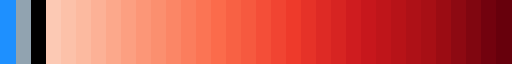

In [35]:
from matplotlib.colors import ListedColormap
ListedColormap(colors, name="FIRE LC Color Map")

Looks good! We may now continue with creating labels for the days. For the sake of readability, we do not define a label for each day, but for every fifth day. Using these labels will cause that in the legend we will see the day of the month, not the day of the year.

In [39]:
labels = [""] * 31
for i in range(5, 31, 5):
    labels[i] = i
labels = base_category_labels + labels

Now, we have to define the actual indices for each month separately, as the value ranges change with every month. For this, we determine the range from the number of days per month (as we only deal with the year 2017, we don't have to bother with the issue of leap years).

In [40]:
days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

Finally we can define an auxiliary method that can create a plot for each month. 

The method works as follows:

- define the JD value range for the month from summming up the days per month.
- Create month-specific arrays month_colors and month_labels by removing the last values. This step is necessary so the arrays have the same length as color_map_values.
- We create an indexers dictionary to indicate which time step of the dataset we are interested in.
- We use that time information to create a more appealing title.
- Lastly, we adjust the size of the figure.

All these parameters are passed to the `plot_catagorical` operation to create a plot that correctly considers

In [41]:
plot_categorical = get_op("plot_categorical")

In [46]:
import pandas as pd
%matplotlib inline

def plot_jd(month: int):
    vmin = 1 + sum(days_per_month[:month - 1])
    vmax = sum(days_per_month[:month])
    month_values = base_category_values + list(range(vmin, vmax))

    month_colors = colors[:days_per_month[month - 1] + 3]
    month_labels = labels[:days_per_month[month - 1] + 3]
    
    time = ds.time.values[month - 1]
    indexers = dict(
        time=time
    )

    month_as_name = pd.Timestamp(ds.time.values[month - 1]).strftime("%B")
    title = f"First day in {month_as_name} 2019 in which a fire was detected"

    figsize=(6, 5)
    
    plot_categorical(
        ds_2017_sub,
        "JD",
        indexers=indexers,
        title=title,
        color_scheme_values=month_values,
        color_scheme_colors=month_colors,
        color_scheme_labels=month_labels,
        properties=dict(figsize=figsize)
    )

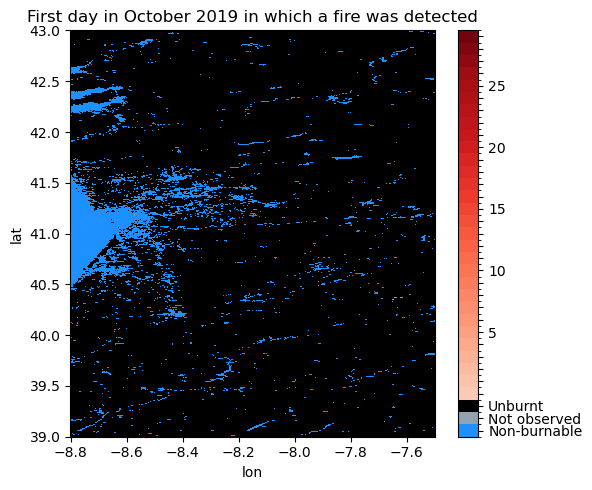

In [47]:
plot_jd(10)

In [60]:
# Select the October 2017 time slice
oct_2017 = ds_2017_sub.sel(time=ds_2017_sub.time.dt.month == 10).squeeze()
oct_2017

<xarray.Dataset> Size: 4MB
Dimensions:    (lat: 1782, lon: 580, bnds: 2)
Coordinates:
    time       datetime64[ns] 8B 2017-10-16T12:00:00
    time_bnds  (bnds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
  * lon        (lon) float64 5kB -8.8 -8.798 -8.795 ... -7.504 -7.502 -7.5
  * lat        (lat) float64 14kB 43.0 43.0 43.0 42.99 ... 39.01 39.01 39.0 39.0
Dimensions without coordinates: bnds
Data variables:
    CL         (lat, lon) uint8 1MB dask.array<chunksize=(1782, 8), meta=np.ndarray>
    JD         (lat, lon) int16 2MB dask.array<chunksize=(1782, 8), meta=np.ndarray>
    LC         (lat, lon) uint8 1MB dask.array<chunksize=(1782, 8), meta=np.ndarray>
Attributes: (12/16)
    Conventions:                CF-1.7
    title:                      esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERR...
    date_created:               2026-04-17T12:27:10.948703
    processing_level:           L3S
    time_coverage_start:        2001-01-01T00:00:00
    time_coverage_end:          2023-01-01T00:00:00
    ...                         ...
    geospatial_lon_max:         -7.498502844663786
    geospatial_lat_resolution:  0.00224573310710241
    geospatial_lat_min:         38.99940113783811
    geospatial_lat_max:         43.00129753468411
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-8.801028046774942 38.99940113783811...

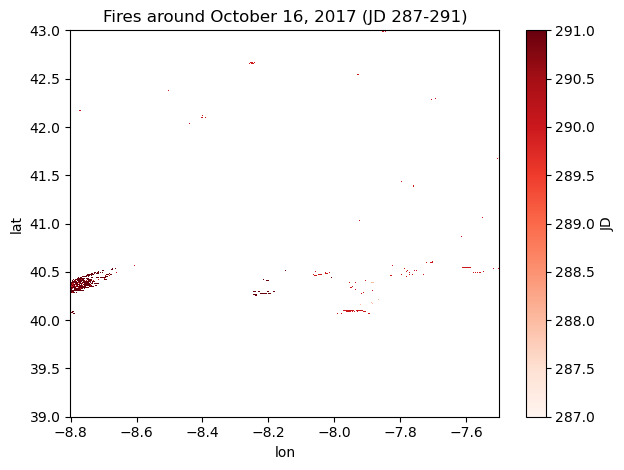

In [61]:
oct_peak = oct_2017.JD.where((oct_2017.JD >= 287) & (oct_2017.JD <= 291))
oct_peak.plot(cmap='Reds')
plt.title("Fires around October 16, 2017 (JD 287-291)")
plt.show()

👉 Next, we will have a look at the circumstances which favoured the wild fire. Let's start with the dataset from [CCI Soil Moisture](https://climate.esa.int/en/projects/soil-moisture/).

### 🛰️ CCI SOIL MOISTURE

We will use the data products from the [CCI Soil Moisture](https://climate.esa.int/en/projects/soil-moisture/) projects. Details about the dataset can be found on the project website and the provided [Product User Guide](https://climate.esa.int/media/documents/ESA_CCI_SM_RD_D4.2_v2_Product_Users_Guide_v09.1_i1.0.pdf).  

With the command `list_ecv_datasets('SOILMOISTURE')` we can call a list of all available datasets which can be loaded via the esa-climate-toolbox.

Before loading the data, we can inspect its structure and look at the attributes, data variables, dimensions, etc. by using the toolbox command `describe_data`.

In [7]:
cci_zarr_store = new_data_store('esa-cci-zarr')
cci_zarr_store.describe_data('ESACCI-SOILMOISTURE-L3S-SSMV-COMBINED-1978-2021-fv07.1.zarr')

🔍 What do we learn from the details?

As you can see in the data ID, we are loading the "combined" datatype. From the Product User Guide we can learn, that the soil moisture is available as active, passive and combined product. The combined product is blending active and passive data which is retrieved via an active C-band scatterometer and L-band radiometer (passive), respectively. 

The temporal resolution of the soil moisture data is daily and covers 1978 - 2021. The spatial resolution is 0.25° which corresponds to a pixel size of approximately 25 km x 25 km on the Iberian Peninsula. The unit of the combined data product is m<sup>3</sup>m<sup>-3</sup>.


In [8]:
# Load the dataset and build the spatial subset
sm_ds = cci_zarr_store.open_data('ESACCI-SOILMOISTURE-L3S-SSMV-COMBINED-1978-2021-fv07.1.zarr')

subset_spatial_op = get_op('subset_spatial')
sm_sub = subset_spatial_op(ds=sm_ds, region=bbox_iberianpeninsula)

#### Calculating monthly means and anomalies
In the next step, we will use the `temporal_aggregation` function from the esa_climate_toolbox to calculate the monthly means of soil moisture. This way, we have the same time resolution as the fire dataset. In another step, we will use the `climatology` operation to calculate the mean soil moisture accross the whole dataset. Then we can use this mean to determine the anomaly of 2017 in comparison to the average and see, if the year has been exceptionally dry. 




In [69]:
# get the function from the esa-climate-toolbox
from esa_climate_toolbox.ops import temporal_aggregation

# Create monthly means
sm_monthly_mean = temporal_aggregation(sm_sub, 
                                method='mean', # here we can define what to do with the data, e.g. 'sum', 'mean'
                                period='M') # 'Y' = year, 'QS-DEC' = quarterly 
display(sm_monthly_mean)

<xarray.Dataset> Size: 42MB
Dimensions:         (time: 518, lat: 34, lon: 60)
Coordinates:
  * lat             (lat) float64 272B 44.12 43.88 43.62 ... 36.38 36.12 35.88
  * lon             (lon) float64 480B -10.62 -10.38 -10.12 ... 3.875 4.125
  * time            (time) datetime64[ns] 4kB 1978-11-30 ... 2021-12-31
Data variables:
    dnflag          (time, lat, lon) float32 4MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    flag            (time, lat, lon) float32 4MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    freqbandID      (time, lat, lon) float32 4MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    mode            (time, lat, lon) float32 4MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    sensor          (time, lat, lon) float64 8MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    sm              (time, lat, lon) float32 4MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    sm_uncertainty  (time, lat, lon) float32 4MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    t0              (time, lat, lon) float64 8MB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.9
    cdm_data_type:                Grid
    comment:                      This dataset was produced with funding of t...
    contact:                      cci_sm_contact@eodc.eu
    creator_email:                cci_sm_developer@eodc.eu
    creator_name:                 Department of Geodesy and Geoinformation, V...
    ...                           ...
    time_coverage_start:          1978-11-30T00:00:00
    time_coverage_start_product:  19781101T000000Z
    title:                        ESA CCI Surface Soil Moisture COMBINED acti...
    tracking_id:                  ad35798e-58e0-488f-b5b9-593874a47700
    geospatial_bounds_crs:        CRS84
    geospatial_bounds:            POLYGON((-10.75 35.75, -10.75 44.25, 4.25 4...

In [70]:
# get the climatology operation
climatology_op = get_op('climatology')
sm_monthly_clim = climatology_op(ds=sm_monthly_mean)
sm_monthly_clim

<xarray.Dataset> Size: 980kB
Dimensions:             (time: 12, lat: 34, lon: 60, nv: 2)
Coordinates:
  * lat                 (lat) float64 272B 44.12 43.88 43.62 ... 36.12 35.88
  * lon                 (lon) float64 480B -10.62 -10.38 -10.12 ... 3.875 4.125
  * time                (time) datetime64[ns] 96B 1978-01-01 ... 1978-12-01
Dimensions without coordinates: nv
Data variables:
    dnflag              (time, lat, lon) float32 98kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    flag                (time, lat, lon) float32 98kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    freqbandID          (time, lat, lon) float32 98kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    mode                (time, lat, lon) float32 98kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    sensor              (time, lat, lon) float64 196kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    sm                  (time, lat, lon) float32 98kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    sm_uncertainty      (time, lat, lon) float32 98kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    t0                  (time, lat, lon) float64 196kB dask.array<chunksize=(1, 34, 43), meta=np.ndarray>
    climatology_bounds  (time, nv) datetime64[us] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.9
    cdm_data_type:                Grid
    comment:                      This dataset was produced with funding of t...
    contact:                      cci_sm_contact@eodc.eu
    creator_email:                cci_sm_developer@eodc.eu
    creator_name:                 Department of Geodesy and Geoinformation, V...
    ...                           ...
    time_coverage_start:          1978-11-30T00:00:00
    time_coverage_start_product:  19781101T000000Z
    title:                        ESA CCI Surface Soil Moisture COMBINED acti...
    tracking_id:                  ad35798e-58e0-488f-b5b9-593874a47700
    geospatial_bounds_crs:        CRS84
    geospatial_bounds:            POLYGON((-10.75 35.75, -10.75 44.25, 4.25 4...

🔍 What do see when looking at the dataset?

We have now created a new dataset using the `climatology` operation. You can see in the time array that there are time steps for each 1st of the month in 1978. These are the times that were attributed to the monthly mean values from 1978-2021. If our data would have been daily, we would have 365 entries and mean values. In our case, we used the monthly data, thus we have 12 monthly means accross the soil moisture data. 
We can use this information now as a base to see how 2017 has been deviating from the average. 

#### 🗺 Now we can create a plot of the soil moisture anomaly

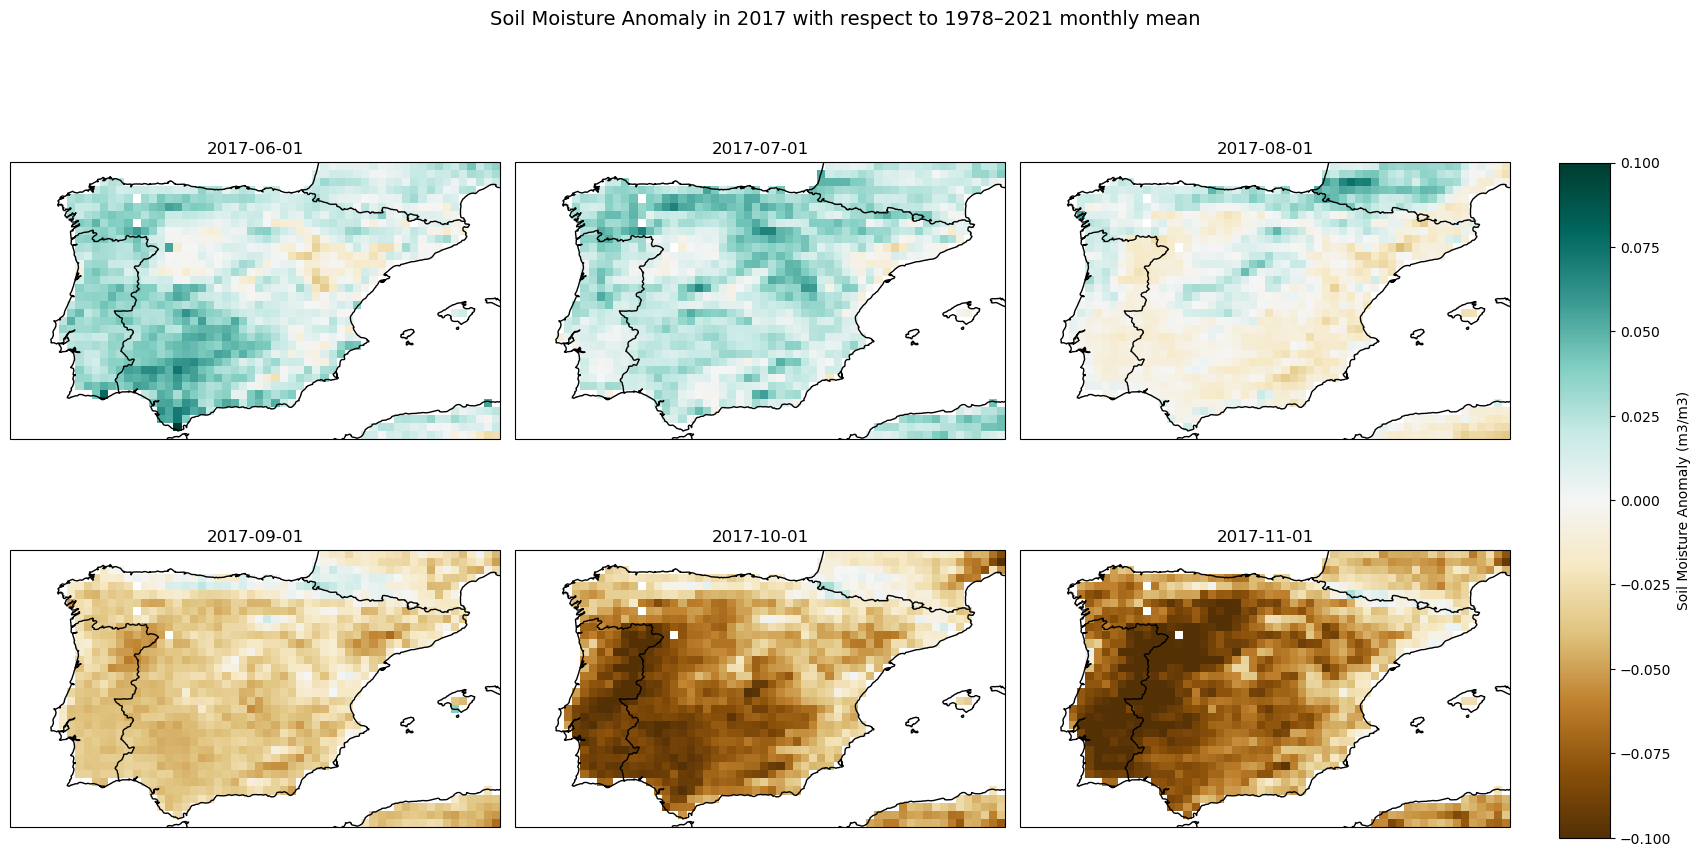

In [71]:
# Define the months to plot
dates = ['2017-06-01','2017-07-01','2017-08-01',
'2017-09-01', '2017-10-01', '2017-11-01']

ncols = 3
nrows = int(np.ceil(len(dates)/ncols))

subplot_width = 5
subplot_height = 4

fig_width = ncols * subplot_width + 2  # +2 for colorbar and margins
fig_height = nrows * subplot_height + 1

fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Loop through the dates to create separate plots for each chosen date
for ax, timestamp in zip(axes, dates):
    climatology_time = f"1978-{str(timestamp[5:7])}-01"
    data = sm_monthly_mean["sm"].sel(time=timestamp, method='nearest') - \
           sm_monthly_clim["sm"].sel(time=climatology_time, method='nearest')

    # plot without colourbar to add one common one outside the loop
    im = data.plot(ax=ax, cmap='BrBG', vmin=-0.1, vmax=0.1,
                   add_colorbar=False)

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(timestamp)

# Remove unused axes, in case len(dates) < nrows*ncols
for ax in axes[len(dates):]:
    fig.delaxes(ax)

# Adding one shared colorbar with the same height as subplots
cbar_ax = fig.add_axes([0.92, 0.1, 0.03, 0.75])  # adapt if wished
fig.colorbar(im, cax=cbar_ax, label='Soil Moisture Anomaly (m3/m3)')

fig.suptitle('Soil Moisture Anomaly in 2017 with respect to 1978–2021 monthly mean',
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar
plt.show()


### 💡 What do we see? 

Looking at the monthly anomaly of soil moisture, we can see that starting with September 2017 the soil has been a lot drier than the average. We might be able to see an increased land surface temperature (LST) as well. Let's have a look at the CCI LST data next. 

### 🛰️ CCI LAND SURFACE TEMPERATURE (LST)

We will use the data products from the [CCI Land Surface Temperature](https://climate.esa.int/en/projects/land-surface-temperature/) project. Details about the dataset can be found on the project website and the provided [Product User Guide](https://admin.climate.esa.int/media/documents/LST-CCI-D4.3-PUG_-_i3r1_-_Product_User_Guide.pdf).  

With the command `list_ecv_datasets('LST')` we can call a list of all available datasets which can be loaded via the esa-climate-toolbox.

Before loading the data, we can once again inspect its structure using  `describe_data`.

In [72]:
cci_zarr_store = new_data_store('esa-cci-zarr')
cci_zarr_store.describe_data('ESACCI-LST-L3S-LST-IRCDR_-0.01deg_1MONTHLY_DAY-1995-2020-fv3.00.zarr')

🔍 What do we learn from the details?

The LST dataset covers 1995 - 2020 with a monthly time resolution and a spatial resolution of 0.01° which correspnds to approximately 1 km2 grid cells on the iberial peninsula. The unit of the LST is Kelvin. 

In [73]:
# Load the LST Dataset
lst_ds = cci_zarr_store.open_data('ESACCI-LST-L3S-LST-IRCDR_-0.01deg_1MONTHLY_DAY-1995-2020-fv3.00.zarr')
lst_ds

<xarray.Dataset> Size: 18TB
Dimensions:          (channel: 2, time: 294, lat: 18000, lon: 36000,
                      length_scale: 294)
Coordinates:
  * channel          (channel) float64 16B 11.0 12.0
  * lat              (lat) float32 72kB -90.0 -89.99 -89.98 ... 89.98 89.99
  * lon              (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0
  * time             (time) datetime64[ns] 2kB 1995-08-01 ... 2020-12-01
Dimensions without coordinates: length_scale
Data variables: (12/14)
    dtime            (time, lat, lon) timedelta64[ns] 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lcc              (time, lat, lon) float32 762GB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst              (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst_unc_loc_atm  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst_unc_loc_cor  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    lst_unc_loc_sfc  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    ...               ...
    lst_uncertainty  (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    n                (time, lat, lon) float32 762GB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    sataz            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    satze            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    solaz            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
    solze            (time, lat, lon) float64 2TB dask.array<chunksize=(1, 2250, 2250), meta=np.ndarray>
Attributes: (12/42)
    Conventions:                CF-1.8
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/6babb8d9a8d...
    cdm_data_type:              grid
    comment:                    These data were produced as part of the ESA L...
    creator_email:              djg20@le.ac.uk
    creator_name:               University of Leicester Surface Temperature G...
    ...                         ...
    summary:                    This file contains level L3S global land surf...
    time_coverage_duration:     P1M
    time_coverage_end:          19700101T000001Z
    time_coverage_resolution:   P1M
    time_coverage_start:        19700101T000001Z
    title:                      ESA LST CCI land surface temperature time ser...

#### Calculating the climatology
As with the soil moisture, we will use the `climatology` operation to calculate the mean LST accross the whole dataset. 




In [74]:
subset_spatial_op = get_op('subset_spatial')
lst_sub = subset_spatial_op(ds=lst_ds, region=bbox_iberianpeninsula)

# get the climatology operation
climatology_op = get_op('climatology')
lst_clim = climatology_op(ds=lst_sub)
lst_clim

<xarray.Dataset> Size: 1GB
Dimensions:             (time: 12, lat: 802, lon: 1476, length_scale: 294,
                         channel: 2, nv: 2)
Coordinates:
  * channel             (channel) float64 16B 11.0 12.0
  * lat                 (lat) float32 3kB 35.99 36.01 36.01 ... 43.99 44.01
  * lon                 (lon) float32 6kB -10.6 -10.58 -10.58 ... 4.145 4.155
  * time                (time) datetime64[ns] 96B 1995-01-01 ... 1995-12-01
Dimensions without coordinates: length_scale, nv
Data variables: (12/15)
    dtime               (time, lat, lon) timedelta64[ns] 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    lcc                 (time, lat, lon) float32 57MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    lst                 (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    lst_unc_loc_atm     (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    lst_unc_loc_cor     (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    lst_unc_loc_sfc     (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    ...                  ...
    n                   (time, lat, lon) float32 57MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    sataz               (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    satze               (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    solaz               (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    solze               (time, lat, lon) float64 114MB dask.array<chunksize=(1, 802, 1060), meta=np.ndarray>
    climatology_bounds  (time, nv) datetime64[us] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                CF-1.8
    catalogue_url:              https://catalogue.ceda.ac.uk/uuid/6babb8d9a8d...
    cdm_data_type:              grid
    comment:                    These data were produced as part of the ESA L...
    creator_email:              djg20@le.ac.uk
    creator_name:               University of Leicester Surface Temperature G...
    ...                         ...
    time_coverage_end:          19700101T000001Z
    time_coverage_resolution:   P1M
    time_coverage_start:        19700101T000001Z
    title:                      ESA LST CCI land surface temperature time ser...
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-10.600010871887207 35.9899978637695...

#### 🗺 Now we can create a plot of the LST

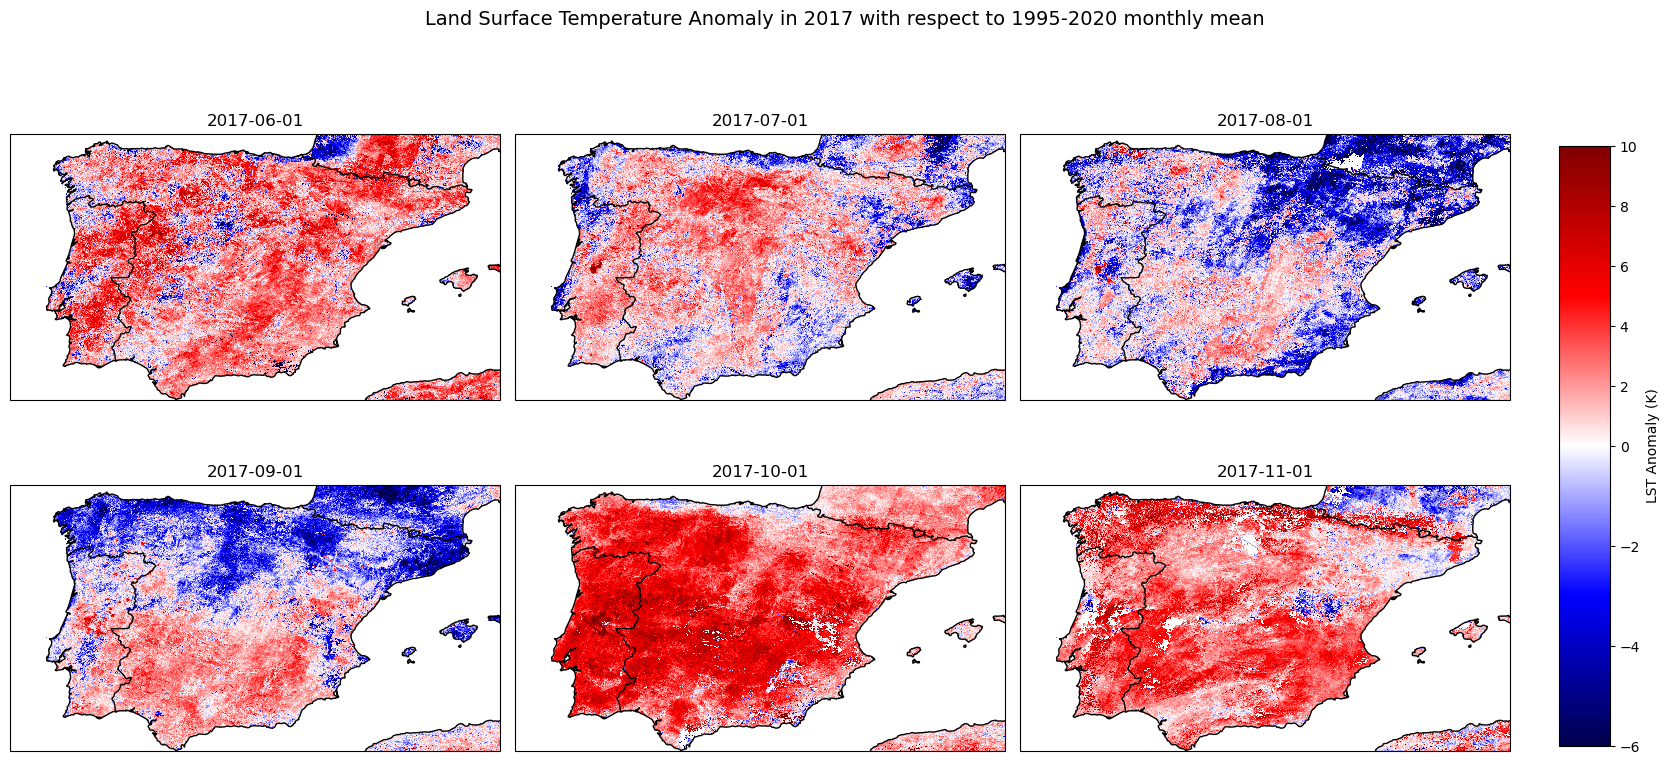

In [75]:
# Define the months to plot
dates = ['2017-06-01','2017-07-01','2017-08-01',
'2017-09-01', '2017-10-01', '2017-11-01']

ncols = 3
nrows = int(np.ceil(len(dates)/ncols))

subplot_width = 5
subplot_height = 4

fig_width = ncols * subplot_width + 2  # +2 for colorbar and margins
fig_height = nrows * subplot_height #+ 1

# define boundaries of the colourbar
norm = TwoSlopeNorm(vmin=-6, vcenter=0, vmax=10)

fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Loop through the dates to create separate plots for each chosen date
for ax, timestamp in zip(axes, dates):
    climatology_time = f"1995-{str(timestamp[5:7])}-01"
    data = lst_sub["lst"].sel(time=timestamp, method='nearest') - \
           lst_clim["lst"].sel(time=climatology_time, method='nearest')

    im = data.plot(
        ax=ax,
        cmap='seismic',
        norm=norm,
        add_colorbar=False
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(timestamp)

# Remove unused axes, in case len(dates) < nrows*ncols
for ax in axes[len(dates):]:
    fig.delaxes(ax)

# Adding one shared colorbar with the same height as subplots
cbar_ax = fig.add_axes([0.92, 0.1, 0.03, 0.75])  # adapt if wished
fig.colorbar(im, cax=cbar_ax, label='LST Anomaly (K)')

fig.suptitle('Land Surface Temperature Anomaly in 2017 with respect to 1995-2020 monthly mean',
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar
plt.show()


### 💡 What do we see? 

Looking at the monthly anomaly of LST, we can see that the temperatures in October were exceptionally high compared to the mean of 1995 - 2020.

Now that we have looked at some circumstances which might have favoured the wild fires, let's look at the impact on the biomass next.

### 🛰️ CCI BIOMASS 
The [CCI Biomass](https://climate.esa.int/en/projects/biomass/) data is available in different resolutions. We will start with a lower resolution and look at the whole peninsula and then look at high resolution data (100 m) where we saw very large burned areas. The list of available biomass datasets can be viewed with `list_ecv_datasets('Biomass')`.

Since the CCI Fire dataset has a resolution of approximately 25 km, we can use the biomass dataset with 25 km resolution as well. We can use the toolbox operation `coregistration` to bring both datasets on the same grid resolution. 

First, we will inspect the time resolution of the dataset. 

In [76]:
# list_ecv_datasets('Biomass')

In [77]:
cci_zarr_store = new_data_store('esa-cci-zarr')
# cci_zarr_store.describe_data('ESACCI-BIOMASS-L4-AGB-MERGED-100m-2010-2020-fv4.0.zarr')

🔍 What do we learn from the details?

The biomass data is available for the years 2007, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021 and 2022 in a yearly resolution. If we want to look at the biomass loss due to the fires in 2017, we can visualise the years 2017 and 2018. 
The biomass dataset contains the parameter **above-ground biomass (agb)** in Mg/ha. For more details about the dataset, you can read the [Product User Guide](https://climate.esa.int/media/documents/D4.3_CCI_PUG_V6.0_20250606.pdf). 

In the next cell, we will load the biomass dataset with 25 km resolution. This dataset is only available as netcdf and can be loaded with the esa-cci datastore. The advantage is, that we can use the bounding box as input right away and don't have to build a spatial subset in an additional step. And we can even define the time range we would like to load. 

In [78]:
# bbox_west = (-9.5,40.5,-8,42.5)
cci_store = new_data_store('esa-cci')
# biomass_100m = cci_zarr_store.open_data(
#     data_id = 'ESACCI-BIOMASS-L4-AGB-MERGED-100m-2010-2020-fv4.0.zarr')

biomass_25km = cci_store.open_data(
    data_id = 'esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.6-0.25000m')

# subset_spatial_op = get_op('subset_spatial')
# biomass_sub = subset_spatial_op(ds=biomass_100m, region=bbox_fire)

### Create mask for the burned area in 2017

To look at the biomass in the most affected areas during the fires in 2017, we can sum up the burned area for each year and then create a mask to determine an area where we'd like to have a closer look at the biomass loss.

#### Downsample fire data to match the grid resolution of biomass data
This code snippet first calculates the `fire_annual_sum` to retrieve the same temporal resolution (yearly), as the biomass dataset. 

Then we normalise the annual fire dataset (`fire_annual_sum`) to standardise its values using the `normalize_op` operation. It then coregisters the normalised fire dataset with the biomass dataset (`biomass_25km`) using the coregister_op operation, aligning their spatial grids and resampling the biomass data to match the fire grid using the "mode" method for categorical data.

Resampling categorical data presents a challenge because traditional statistical methods like averaging are not suitable. Instead, mode-based aggregation must be used to preserve the integrity of categorical classifications, ensuring that the dominant class in each new grid cell accurately reflects the underlying data.

The goal is to create a mask of the areas with the most burned area. The threshold is set to 1e8 m2 but can be adapted as wished. 


In [79]:
# get the temporal aggregation function from the esa-climate-toolbox
from esa_climate_toolbox.ops import temporal_aggregation

# Calculate the sum of burned areas for each year:
fire_annual_sum = temporal_aggregation(fire_sub, 
                                method='sum', # here we can define what to do with the data, e.g. 'sum', 'mean'
                                period='Y') # 'Y' = year, 'QS-DEC' = quarterly 

# normalize the dataset 
normalize_ds = get_op('normalize')
fire_norm = normalize_ds(fire_annual_sum)

If you want to get more information on the operations you can use with the toolbox, you can use the `get_op_meta_info` function as shown below.

In [49]:
from IPython.display import JSON
from esa_climate_toolbox.core import get_op_meta_info

JSON(get_op_meta_info('coregister'))


<IPython.core.display.JSON object>

In [82]:
# JSON(get_op_meta_info('normalize'))

In [85]:
# define and call the toolbox functions we will use below
normalize_op = get_op('normalize')
select_var = get_op("select_var")
coregister_op = get_op('coregister')

# first we normalise the datasets
fire_annual_norm = normalize_op(ds=fire_annual_sum) #normalize_op(ds=fire_annual_sum.sum(dim=("vegetation_class","nv"))) 
biomass_norm = normalize_op(ds=biomass_25km)

# now we use the select_var function to choose which parameters we would like to use for the coregistration function
fire_for_coreg = select_var(fire_annual_norm, var=["burned_area"])
biomass_for_coreg = select_var(biomass_norm, var=["agb"])

# now we can apply the coregister function on the preared dataset and will get a biomass dataset with the same resolution as the fire dataset
biomass_res_ds = coregister_op(
    ds_primary = fire_for_coreg,
    ds_replica = biomass_for_coreg,
    method_ds = "mode"
    )

# to check the dimensions we can display the datasets and see that both have 34 latitudes and 60 longitudes
# display(biomass_res_ds)
# display(fire_annual_norm)

Now we can create the masked using the burned area and apply it to the biomass data with the same latitude and longitude dimensions.

In [ ]:
# # Define threshold 
# burn_threshold = 1e8 # m² this can be adapted

# fire_2017 = fire_annual_norm.sel(time='2017').compute() 
# # Find all pixels above threshold 
# high_burned_area = fire_2017.burned_area.where(fire_2017.burned_area >= burn_threshold)

We can create a quick and simple plot to see if the mask worked:

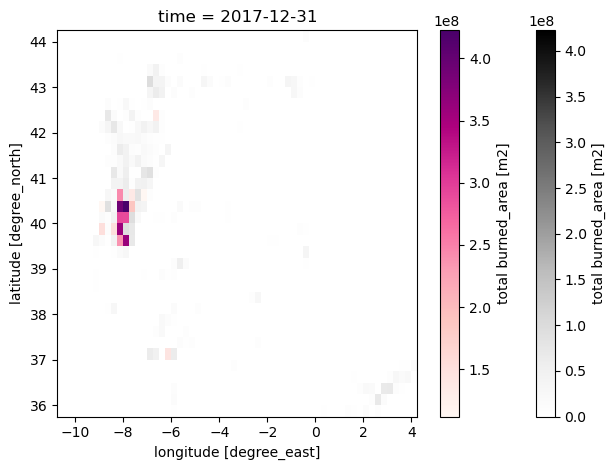

In [ ]:

# fire_2017.burned_area.plot(cmap='Greys')
# high_burned_area.plot(cmap='RdPu')

# plt.show()

In [ ]:
# Let's create a mask for the burned area which we can apply on the biomass dataset 
burn_mask_2017 = (
    fire_annual_norm
    .sel(time="2017")
    .burned_area
    .values >= burn_threshold
)
display(burn_mask_2017)

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])

In [ ]:
# and now we can apply this mask on the biomass dataset:
biomass_masked = biomass_res_ds.agb.where(burn_mask_2017)
display(biomass_masked)

<xarray.DataArray 'agb' (time: 10, lat: 34, lon: 60)> Size: 82kB
dask.array<where, shape=(10, 34, 60), dtype=float32, chunksize=(10, 34, 43), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 272B 35.88 36.12 36.38 36.62 ... 43.62 43.88 44.12
  * lon      (lon) float64 480B -10.62 -10.38 -10.12 ... 3.625 3.875 4.125
  * time     (time) datetime64[ns] 80B 2007-07-02 2010-07-02 ... 2022-07-02
Attributes: (12/14)
    long_name:         Above-ground biomass
    grid_mapping:      crs
    units:             Mg/ha
    valid_min:         0.0
    valid_max:         10000.0
    orig_data_type:    int16
    ...                ...
    shape:             [10, 720, 1440]
    chunk_sizes:       [10, 360, 720]
    file_chunk_sizes:  [10, 360, 720]
    data_type:         int16
    dimensions:        ['time', 'lat', 'lon']
    file_dimensions:   ['time', 'lat', 'lon']

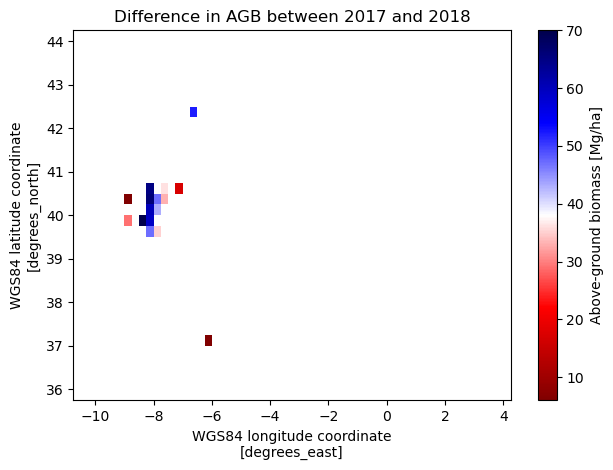

In [121]:
from esa_climate_toolbox.ops import diff
biomass_diff = diff(
    ds = biomass_res_ds,
    ds2 = biomass_res_ds.sel(time='2017-1-1',method='nearest')
)


plot_op = get_op('plot')

plot_op(
    ds=biomass_res_ds.where(burn_mask_2017),  # Dataset variable
    var='agb',       # Variable you want to plot
    indexers={'time': '2018-01-01'},  # Specify the date
    title="Difference in AGB between 2017 and 2018",
    properties="cmap='seismic_r'"  # Pass other properties here, such as color
)

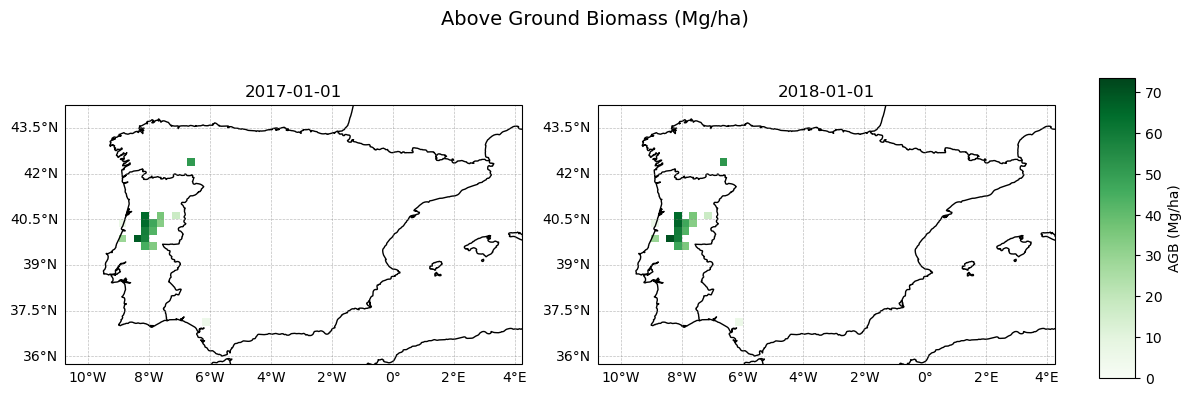

In [111]:
# biomass_masked.sel(time="2017").plot()


dates = ['2017-01-01','2018-01-01']

ncols = 2
nrows = int(np.ceil(len(dates)/ncols))

subplot_width = 5
subplot_height = 4

fig_width = ncols * subplot_width + 2  # +2 for colorbar and margins
fig_height = nrows * subplot_height #+ 1


fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Loop through the dates to create separate plots for each chosen date
for ax, timestamp in zip(axes, dates):
    data = biomass_masked.sel(time=timestamp, method='nearest')

    im = data.plot(
        ax=ax,
        cmap='Greens',
        vmin=0,vmax=np.nanpercentile(biomass_masked, 99),
        add_colorbar=False
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(timestamp)
        # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                      alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

# Remove unused axes, in case len(dates) < nrows*ncols
for ax in axes[len(dates):]:
    fig.delaxes(ax)

# Adding one shared colorbar with the same height as subplots
cbar_ax = fig.add_axes([0.92, 0.1, 0.03, 0.75])  # adapt if wished
fig.colorbar(im, cax=cbar_ax, label="AGB (Mg/ha)")

fig.suptitle('Above Ground Biomass (Mg/ha)',
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar
plt.show()



# Notes
- not happy with the filtering yet -> could e.g. plot biomass accross the iberian peninsula and then rectancles around the most burned area
- would like to have a timeseries showing the loss of biomass due to the fires - but first need to improve the filter method
- plan was to then use one of the pixels above and plot only this area with the 100 m biomass data to see in detail what was lost
- Vegetation Parameters are not covering a whole area and finding the correct stations for the plotting is quite diffiult at the moment
- the HR LC dataset does not cover the Iberian Peninsula 
- the LC dataset is only reaching until 2015 - mailed Tonio about it already
- not very happy yet with how the coregister etc. is working, since many new datasets are created in the process which fill up the workspace on jupyter lab -> this needs improvement

# Old Plot - data not yet loaded, just kept it as inspiration for later:

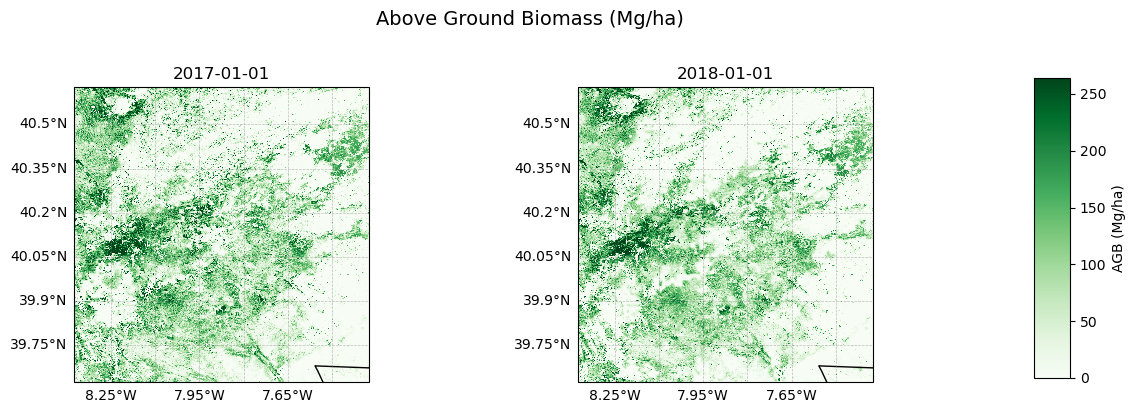

In [83]:
dates = ['2017-01-01','2018-01-01']

ncols = 2
nrows = int(np.ceil(len(dates)/ncols))

subplot_width = 5
subplot_height = 4

fig_width = ncols * subplot_width + 2  # +2 for colorbar and margins
fig_height = nrows * subplot_height #+ 1


fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Loop through the dates to create separate plots for each chosen date
for ax, timestamp in zip(axes, dates):
    data = biomass_sub["agb"].sel(time=timestamp, method='nearest')

    im = data.plot(
        ax=ax,
        cmap='Greens',
        vmin=0,vmax=np.nanpercentile(biomass_sub["agb"], 99),
        add_colorbar=False
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(timestamp)
        # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                      alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

# Remove unused axes, in case len(dates) < nrows*ncols
for ax in axes[len(dates):]:
    fig.delaxes(ax)

# Adding one shared colorbar with the same height as subplots
cbar_ax = fig.add_axes([0.92, 0.1, 0.03, 0.75])  # adapt if wished
fig.colorbar(im, cax=cbar_ax, label="AGB (Mg/ha)")

fig.suptitle('Above Ground Biomass (Mg/ha)',
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar
plt.show()


In [ ]:
from esa_climate_toolbox.ops import diff
biomass_diff = diff(
    ds = biomass_sub,
    ds2 = biomass_sub.sel(time='2017-1-1',method='nearest')
)

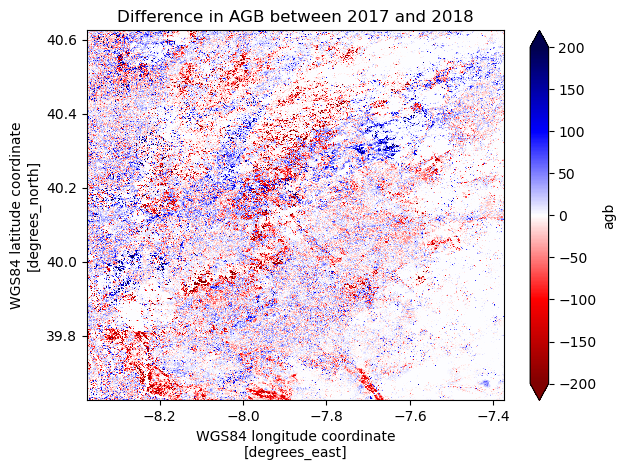

In [85]:
dates = ['2018-01-01']

plot_op = get_op('plot')

plot_op(
    ds=biomass_diff,  # Dataset variable
    var='agb',       # Variable you want to plot
    indexers={'time': '2018-01-01'},  # Specify the date
    title="Difference in AGB between 2017 and 2018",
    properties="cmap='seismic_r',vmin=-200,vmax=200",  # Pass other properties here, such as color
)